In [40]:
%%capture
# !pip install pandas matplotlib

1. Count Valid Global Entries for Each Country (Includes only sites succeeded in all crawlers)

=== Total Valid Entries and Unique Sites For Common US Top 525 Websites (Includes only sites succeeded in all crawlers) ===


,Country,Valid Entries,Unique Sites
9,United States,5815,391
0,Australia,5548,392
6,South Africa,4910,382
2,Canada,4721,368
4,India,4653,386
1,Brazil,4642,387
7,South Korea,4489,380
5,Singapore,4200,377
3,Germany,2828,374
8,Spain,2342,361


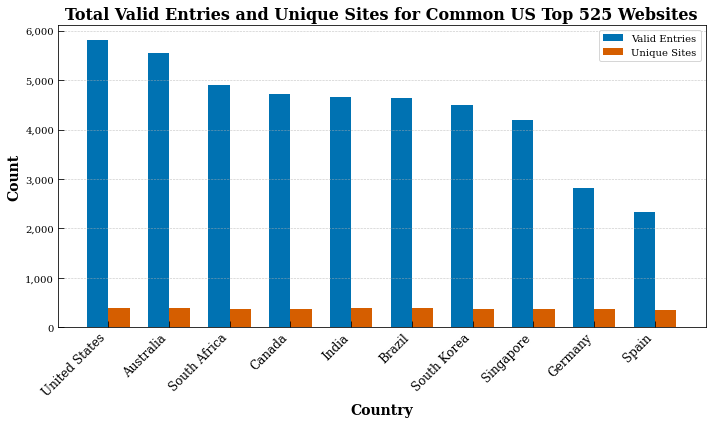

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# For Jupyter notebooks; remove if not needed
%matplotlib inline

# --------------------------------------------
# 1. Load the preprocessed combined CSV file
# --------------------------------------------
combined_csv_path = "../analysis_data/entries/combined_all_countries.csv"
df = pd.read_csv(combined_csv_path)

# --------------------------------------------
# 2. Define "global" valid entries:
#    - Global entries: those that are NOT country-specific AND
#      have no crawl failure (i.e. CountriesCrawlFailed is False)
# --------------------------------------------
df['global_valid'] = (~df['countrySpecificEntries']) & (~df['CountriesCrawlFailed'])
df_global = df[df['global_valid']]

# --------------------------------------------
# 3. Map country names to proper names, count valid entries,
#    and compute unique sites (rootUrl) per country
# --------------------------------------------
country_mapping = {
    'unitedstates': 'United States',
    'australia': 'Australia',
    'southafrica': 'South Africa',
    'canada': 'Canada',
    'india': 'India',
    'brazil': 'Brazil',
    'southkorea': 'South Korea',
    'singapore': 'Singapore',
    'germany': 'Germany',
    'spain': 'Spain'
}

results = []
for country, group in df_global.groupby('country'):
    valid_count = len(group)
    unique_sites = group['rootUrl'].nunique()  # Count unique sites for the country
    proper_country = country_mapping.get(country.lower(), country.capitalize())
    results.append((proper_country, valid_count, unique_sites))

results_df = pd.DataFrame(results, columns=['Country', 'Valid Entries', 'Unique Sites'])
results_df = results_df.sort_values('Valid Entries', ascending=False)

print("=== Total Valid Entries and Unique Sites For Common US Top 525 Websites (Includes only sites succeeded in all crawlers) ===")
display(results_df)

# --------------------------------------------
# 4. Plot the results in a professional NDSS paper style
#    (Grouped bar chart: one bar for Valid Entries and one for Unique Sites)
# --------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'grid.linestyle': '--',
    'grid.alpha': 0.6
})

fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width and compute positions for the grouped bars
width = 0.35
x = range(len(results_df['Country']))

bars1 = ax.bar([i - width/2 for i in x], results_df['Valid Entries'], width=width,
               label='Valid Entries', color='#0072B2')
bars2 = ax.bar([i + width/2 for i in x], results_df['Unique Sites'], width=width,
               label='Unique Sites', color='#D55E00')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Country'], rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Entries and Unique Sites for Common US Top 525 Websites', fontsize=16, fontweight='bold')

# Add gridlines only on the y-axis
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend()
plt.tight_layout()
plt.show()


2. Analyze and Plot by Top-Level Permission Types

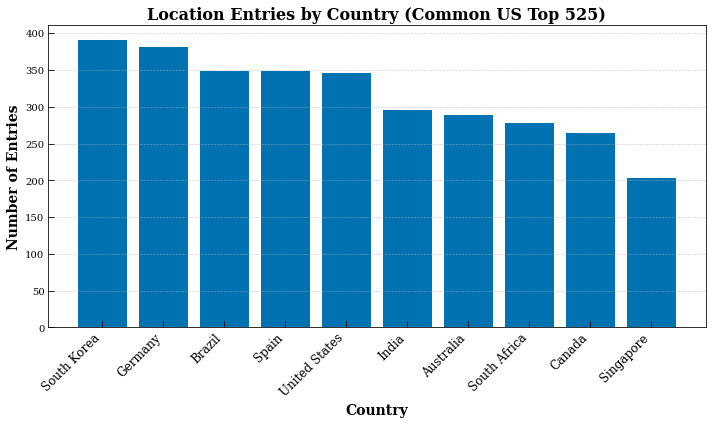

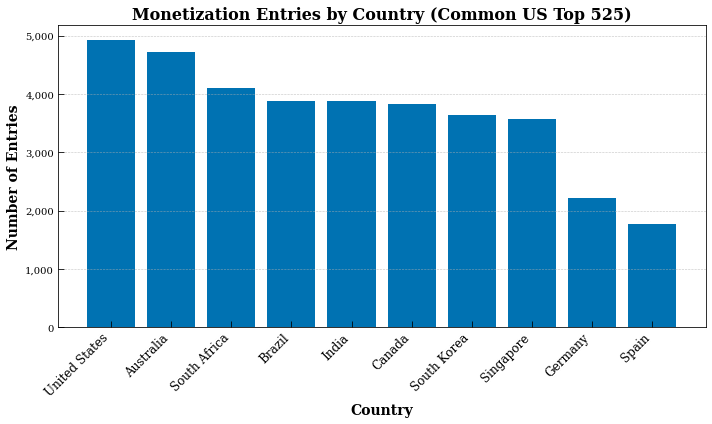

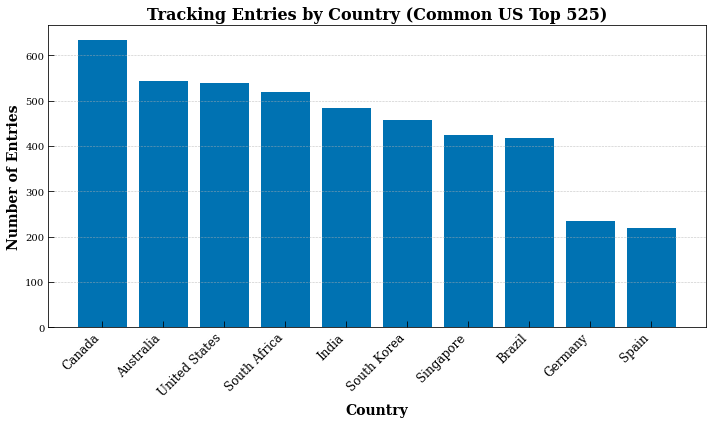

In [42]:
# List of top-level permission types
permission_types = ['location', 'monetization', 'tracking']

for p_type in permission_types:
    # Filter for this permission from the global (non-country-specific & successful crawl) data.
    subset = df_global[df_global['permission'] == p_type]
    
    # Group by country and count the entries
    grouped = subset.groupby('country').size().reset_index(name='Count')
    # Apply country name mapping
    grouped['country'] = grouped['country'].str.lower().map(country_mapping).fillna(grouped['country'].str.capitalize())
    # Sort by descending count
    grouped = grouped.sort_values('Count', ascending=False)
    
    # Plot the counts for the current permission type
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the bars
    bars = ax.bar(grouped['country'], grouped['Count'], color='#0072B2')

    # Set x-ticks explicitly
    ax.set_xticks(range(len(grouped['country'])))
    ax.set_xticklabels(grouped['country'], rotation=45, ha='right', fontsize=12)

    # Labels and title
    ax.set_xlabel('Country', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
    ax.set_title(f'{p_type.capitalize()} Entries by Country (Common US Top 525)',
                 fontsize=16, fontweight='bold')

    # Add a grid
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    ax.xaxis.grid(False)

    # Format y-axis numbers to include commas
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.tight_layout()
    plt.show()


3. Pivot Data by Permission Type and Plot a Stacked Bar Chart

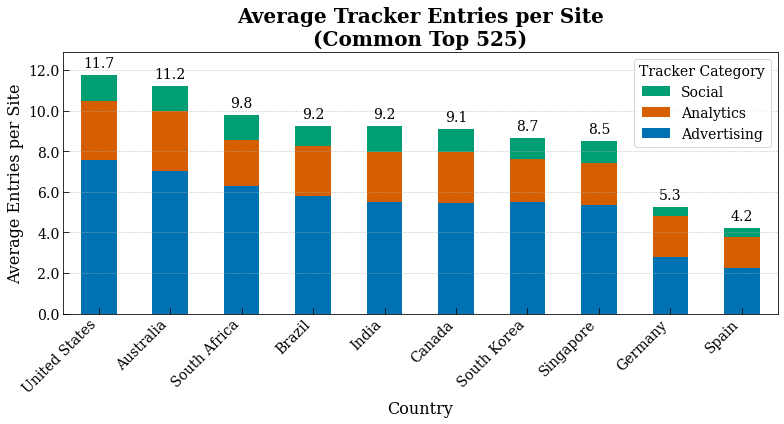

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import re

# ------------------ Step 1: Monetization-only pivot -------------------
desired_order_mon = ['Advertising', 'Analytics', 'Social']
colours            = ['#0072B2', '#D55E00', '#009E73']

# filter for monetization entries
df_monet = df_global[df_global['permission'] == 'monetization']

# pivot counts per country and typ
df_stacked = (
    df_monet
      .groupby(['country', 'typ'])
      .size()
      .unstack(fill_value=0)
)

# harmonise column names & enforce display order
df_stacked.columns = df_stacked.columns.str.capitalize()
df_stacked = df_stacked.reindex(
    columns=[c for c in desired_order_mon if c in df_stacked.columns],
    fill_value=0
)

# ------------------ Step 2: Prettify country names ---------------------
country_mapping = {
    'unitedstates': 'United States',
    'australia': 'Australia',
    'southafrica': 'South Africa',
    'canada': 'Canada',
    'india': 'India',
    'brazil': 'Brazil',
    'southkorea': 'South Korea',
    'singapore': 'Singapore',
    'germany': 'Germany',
    'spain': 'Spain'
}

df_stacked.index = (
    pd.Series(df_stacked.index)
      .str.lower()
      .str.replace(r'\W+', '', regex=True)
      .map(country_mapping)
      .fillna(pd.Series(df_stacked.index).str.capitalize())
)

# ------------------ Step 3: Compute averages per site -----------------
FIXED_SUCCESS_SITES = 525 - 105  # uniform base of 420 sites

df_avg = df_stacked.div(FIXED_SUCCESS_SITES, axis=0)

# sort countries by total descending
df_avg = df_avg.loc[
    df_avg.sum(axis=1).sort_values(ascending=False).index
]

# ------------------ Step 4: Plot ---------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

df_avg.plot(
    kind='bar',
    stacked=True,
    color=colours,
    ax=ax
)

# labels & ticks
ax.set_xticks(range(len(df_avg.index)))
ax.set_xticklabels(df_avg.index, rotation=45, ha='right', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.set_xlabel('Country', fontsize=16)
ax.set_ylabel('Average Entries per Site', fontsize=16)
ax.set_title(
    'Average Tracker Entries per Site\n(Common Top 525)',
    fontsize=20, fontweight='bold'
)

# grid & formatter
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0f}')
)

# custom legend patches
legend_patches = [
    Patch(facecolor='#009E73', label='Social'),
    Patch(facecolor='#D55E00', label='Analytics'),
    Patch(facecolor='#0072B2', label='Advertising')
]
ax.legend(
    handles=legend_patches,
    title='Tracker Category',
    fontsize=14, title_fontsize=14,
    loc='upper right'
)

# extend y-axis for annotations
max_total = df_avg.sum(axis=1).max()
ax.set_ylim(0, max_total * 1.1)

# annotate overall average
for i, total in enumerate(df_avg.sum(axis=1)):
    ax.text(
        i,
        total + max_total * 0.02,
        f'{total:.1f}',
        ha='center', va='bottom',
        fontsize=14,
        clip_on=False
    )

plt.tight_layout()

# save and show
fig.savefig(
    'monetization_subtype.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


Per‐country average Monetization entries per site:
country
Australia         9.3
Brazil            7.6
Canada            7.6
Germany           4.3
India             7.7
Singapore         7.6
South Africa      8.2
South Korea       7.3
Spain             3.5
United States    10.4
dtype: float64

Overall average Monetization entries per site (all countries combined): 7.3


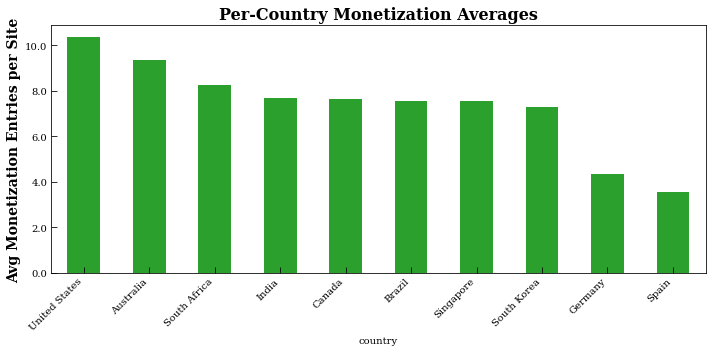

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

# --- Step 1: Read the global error counts CSV ---
err_df = pd.read_csv('../Error_Analysis/global_common_error_count.csv')  # Country,Error Count
err_df['key'] = (
    err_df['Country']
          .str.lower()
          .str.replace(r'\W+', '', regex=True)
)
error_counts = err_df.set_index('key')['Error Count']

# --- Step 2: Pivot the global data by country & permission ---
df_stacked = (
    df_global
      .groupby(['country', 'permission'])
      .size()
      .unstack(fill_value=0)
)

# --- Step 3: Remap & prettify country display names ---
df_stacked.index = (
    pd.Series(df_stacked.index)
      .str.lower()
      .map(country_mapping)
      .fillna(pd.Series(df_stacked.index).str.capitalize())
)
df_stacked.columns = df_stacked.columns.str.capitalize()

# --- Step 4: Order permission columns by overall count ---
perm_order = df_stacked.sum().sort_values(ascending=False).index.tolist()
df_stacked = df_stacked[perm_order]  # still raw counts here

# --- Step 5: Compute success_sites per country (525 – error_count) ---
norm_keys = (
    pd.Series(df_stacked.index, index=df_stacked.index)
      .str.lower()
      .str.replace(r'\W+', '', regex=True)
)
success_sites = (525 - norm_keys.map(error_counts).fillna(0).astype(int))

# --- Step 6: Compute average per site for Monetization only ---
# raw monetization counts
raw_monet = df_stacked['Monetization']
# per-country average
avg_monet = raw_monet / success_sites

# --- Step 7: Compute overall weighted average across all countries ---
total_raw_monet = raw_monet.sum()
total_sites = success_sites.sum()
overall_avg = total_raw_monet / total_sites

print(f"Per‐country average Monetization entries per site:\n{avg_monet.round(1)}\n")
print(f"Overall average Monetization entries per site (all countries combined): {overall_avg:.1f}")

# (Optional) if you still want a bar‐plot of per‐country averages:
fig, ax = plt.subplots(figsize=(10, 5))
avg_monet.sort_values(ascending=False).plot(
    kind='bar',
    color='#2ca02c',
    ax=ax
)
ax.set_ylabel('Avg Monetization Entries per Site', fontsize=14, fontweight='bold')
ax.set_title('Per-Country Monetization Averages', fontsize=16, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.1f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


4. Location Subcategories by Country (Stacked)

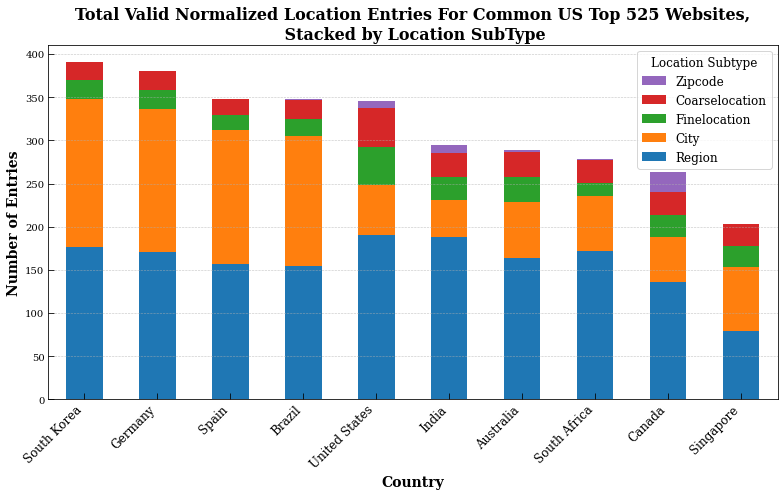

In [45]:
# Filter global data for permission == 'Location'
df_location = df_global[df_global['permission'] == 'location']

# Group by [country, typ] and count the number of entries
df_location_grouped = df_location.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_location_grouped.index = pd.Series(df_location_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_location_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_location_grouped.columns = df_location_grouped.columns.str.capitalize()

# Define the desired order for location subcategories
desired_order_loc = ['Region', 'City', 'Finelocation', 'Coarselocation', 'Zipcode']
df_location_grouped = df_location_grouped.reindex(columns=desired_order_loc, fill_value=0)

# Sort countries by total count (descending)
df_location_grouped = df_location_grouped.loc[df_location_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(11, 7))

# Plot stacked bar chart
df_location_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 7),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_location_grouped.index)))
ax.set_xticklabels(df_location_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Location Entries For Common US Top 525 Websites,\n Stacked by Location SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Location Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


5. Monetization Subcategories by Country (Stacked)

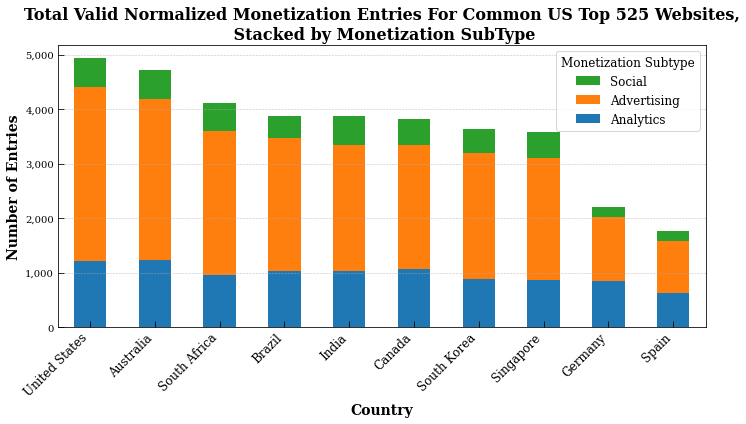

In [46]:
# Filter global data for permission == 'Monetization'
df_monet = df_global[df_global['permission'] == 'monetization']

# Group by [country, typ] and count the number of entries
df_monet_grouped = df_monet.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_monet_grouped.index = pd.Series(df_monet_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_monet_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_monet_grouped.columns = df_monet_grouped.columns.str.capitalize()

# Define the desired order for monetization subcategories
desired_order_mon = ['Analytics', 'Advertising', 'Social']
df_monet_grouped = df_monet_grouped.reindex(columns=desired_order_mon, fill_value=0)

# Sort countries by total count (descending)
df_monet_grouped = df_monet_grouped.loc[df_monet_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar chart
df_monet_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    linewidth=1.2,
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_monet_grouped.index)))
ax.set_xticklabels(df_monet_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Monetization Entries For Common US Top 525 Websites,\n Stacked by Monetization SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Monetization Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


3. Stacked Bar for Tracking Subcategories

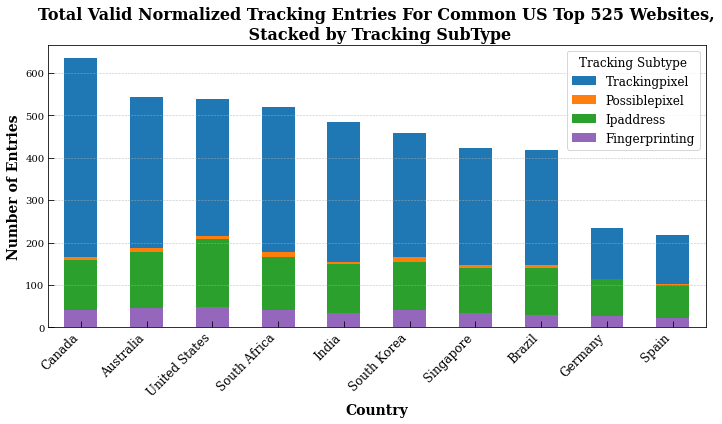

In [47]:
# Filter global data for permission == 'Tracking'
df_tracking = df_global[df_global['permission'] == 'tracking']

# Group by [country, typ] and count the number of entries
df_tracking_grouped = df_tracking.groupby(['country', 'typ']).size().unstack(fill_value=0)

# Apply country mapping
df_tracking_grouped.index = pd.Series(df_tracking_grouped.index).str.lower().map(country_mapping).fillna(
    pd.Series(df_tracking_grouped.index).str.capitalize())

# Capitalize subcategory column names
df_tracking_grouped.columns = df_tracking_grouped.columns.str.capitalize()

# Define the desired order for tracking subcategories
desired_order_track = ['Fingerprinting', 'Ipaddress', 'Possiblepixel', 'Trackingpixel']
df_tracking_grouped = df_tracking_grouped.reindex(columns=desired_order_track, fill_value=0)

# Sort countries by total count (descending)
df_tracking_grouped = df_tracking_grouped.loc[df_tracking_grouped.sum(axis=1).sort_values(ascending=False).index]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stacked bar chart
df_tracking_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#9467bd', '#2ca02c', '#ff7f0e', '#1f77b4'],
    ax=ax
)

# Set x-ticks explicitly
ax.set_xticks(range(len(df_tracking_grouped.index)))
ax.set_xticklabels(df_tracking_grouped.index, rotation=45, ha='right', fontsize=12)

# Labels and title
ax.set_xlabel('Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=14, fontweight='bold')
ax.set_title('Total Valid Normalized Tracking Entries For Common US Top 525 Websites,\n Stacked by Tracking SubType', fontsize=16, fontweight='bold')

# Add a grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
ax.xaxis.grid(False)

# Format y-axis numbers to include commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Set legend order to match stacked order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Tracking Subtype', fontsize=12, title_fontsize=12, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()
